# Laboratório — A* e heurísticas

Neste laboratório o código está completo. A sua tarefa é **executar, alterar parâmetros, observar e responder a cinco questões**. Não precisa de escrever funções.

## Como trabalhar
1. Abra este notebook no Google Colab e guarde uma cópia no seu Drive. Não é necessária GPU.
2. Execute as células pela ordem apresentada. O código usa apenas Python, pandas e matplotlib, disponíveis no Colab.
3. Altere apenas os parâmetros assinalados com **ALTERAR**. Volte a executar a célula após cada alteração.
4. Preencha as células **Resposta** com valores observados e explicações. As execuções ficam registadas no histórico da sessão.
5. Entregue o notebook com as respostas e os resultados guardados. Reiniciar a sessão ou repetir a preparação limpa o histórico.

**Objetivos:** interpretar A* e compará-lo com UCS como referência; distinguir caminho de ordem de retirada; observar atualizações de custo; testar admissibilidade e consistência; compreender reaberturas e comparar heurísticas.

## O que vamos observar?
- **UCS:** escolhe o menor custo acumulado, `g`.
- **A\*:** escolhe o menor `g + h`. Atualiza custos e pais quando encontra um caminho estritamente melhor.
- **OPEN:** estados descobertos que aguardam expansão; a tabela mostra-os por prioridade.
- **CLOSED:** estados já expandidos. Um estado reaberto é removido de CLOSED e regressa a OPEN.

O objetivo é testado **ao retirar de OPEN, antes da expansão**: conta como retirada, mas não como expansão. Os empates são FIFO; atualizar um estado em OPEN conserva a antiguidade, reabri-lo cria uma nova entrada. No grafo dos slides, os sucessores são gerados por ordem alfabética.

`g` é um custo de caminho, `h` é uma estimativa e `c(n,m)` é o custo de uma ligação. O **custo da solução** é diferente do **trabalho de procura**, medido aqui em expansões e máximo de estados em OPEN.

A fila de prioridade é representada por um dicionário e seleção do mínimo para tornar o código legível. Esta escolha serve para os pequenos exemplos; não se pretende comparar tempos de implementações otimizadas.


In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

historico = []

def procurar(grafo, inicio, objetivo, h, algoritmo="A*", reabrir=True):
    """Pesquisa em grafo; OPEN tem um único registo por estado."""
    assert algoritmo in ("UCS", "A*")
    assert inicio in grafo and objetivo in grafo
    assert all(math.isfinite(h[n]) and h[n] >= 0 for n in grafo)
    assert all(v in grafo and math.isfinite(c) and c >= 0
               for adj in grafo.values() for v, c in adj.items())
    g, pai = {inicio: 0}, {inicio: None}
    # Valor de OPEN = ordem de inserção (FIFO em empate).
    aberto, fechado, contador = {inicio: 0}, {}, 1
    retiradas, expandidos, eventos, passos = [], [], [], []
    max_open = 1
    def prioridade(v):
        return g[v] if algoritmo == "UCS" else g[v] + h[v]
    def registar(operacao):
        ordem = sorted(aberto, key=lambda v: (prioridade(v), aberto[v]))
        passos.append({"Operação": operacao,
            "OPEN (estado:prioridade)": str([(v, round(prioridade(v), 3)) for v in ordem]),
            "CLOSED": str(list(fechado))})
    registar("Inicial")
    caminho = None
    while aberto:
        atual = min(aberto, key=lambda v: (prioridade(v), aberto[v]))
        del aberto[atual]
        retiradas.append(atual)
        if atual == objetivo:
            caminho, v = [], atual
            while v is not None:
                caminho.append(v); v = pai[v]
            caminho.reverse()
            registar(f"Retirar {atual}: objetivo")
            break
        fechado[atual] = g[atual]
        expandidos.append(atual)
        for vizinho in sorted(grafo[atual]):
            candidato = g[atual] + grafo[atual][vizinho]
            if candidato >= g.get(vizinho, math.inf):
                continue
            anterior = g.get(vizinho)
            estava_fechado = vizinho in fechado
            if estava_fechado and not reabrir:
                eventos.append({"Ao expandir": atual, "Estado": vizinho,
                    "g anterior": anterior, "g candidato": candidato,
                    "Decisão": "Melhoria ignorada: está em CLOSED"})
                continue
            g[vizinho], pai[vizinho] = candidato, atual
            if estava_fechado:
                del fechado[vizinho]
            if vizinho not in aberto:
                aberto[vizinho] = contador; contador += 1
            eventos.append({"Ao expandir": atual, "Estado": vizinho,
                "g anterior": anterior, "g candidato": candidato,
                "Decisão": "Reabrir" if estava_fechado else
                    "Descobrir" if anterior is None else "Atualizar OPEN"})
        max_open = max(max_open, len(aberto))
        registar(f"Expandir {atual}")
    return dict(caminho=caminho, custo=g[objetivo] if caminho is not None else math.inf,
                retiradas=retiradas, expandidos=expandidos, max_open=max_open,
                passos=passos, eventos=eventos)


def grafo_slides(custo_ce=10):
    assert isinstance(custo_ce, (int, float)) and math.isfinite(custo_ce) and custo_ce > 0
    arestas=[("a","b",4),("a","c",3),("b","f",5),("b","e",12),
             ("c","e",custo_ce),("c","d",7),("d","e",2),("e","z",5),("f","z",16)]
    grafo={v:{} for v in "abcdefz"}
    for u,v,c in arestas:
        grafo[u][v]=c; grafo[v][u]=c
    h=dict(zip("abcdefz", [14,12,11,6,4,11,0]))
    return grafo,h


def verificar(grafo, objetivo, h):
    # UCS serve apenas de referência para avaliar h nestes pequenos problemas.
    # Estes cálculos não são usados pela procura que está a ser comparada.
    zero={n:0 for n in grafo}
    otimos={n:procurar(grafo,n,objetivo,zero,"UCS")["custo"] for n in grafo}
    tabela=pd.DataFrame([{"Estado":str(n),"h":h[n],"h*":otimos[n],
        "Admissível neste estado":0 <= h[n] <= otimos[n]+1e-9} for n in grafo])
    falhas=[{"Arco":f"{u} → {v}","h(u)":h[u],"c+h(v)":c+h[v]}
            for u in grafo for v,c in grafo[u].items() if h[u] > c+h[v]+1e-9]
    admissivel=bool(tabela["Admissível neste estado"].all()) and h[objetivo]==0
    consistente=not falhas and h[objetivo]==0
    print(f"Admissível: {admissivel} | Consistente: {consistente}")
    display(tabela)
    if falhas: display(pd.DataFrame(falhas))
    return admissivel, consistente


def mostrar(etapa, grafo, inicio, objetivo, h, algoritmos=("UCS","A*"),
            reabrir=True, detalhes=False, parametros=""):
    linhas=[]; resultados={}
    for algoritmo in algoritmos:
        r=procurar(grafo,inicio,objetivo,h,algoritmo,reabrir)
        resultados[algoritmo]=r
        linha={"Experiência":etapa,"Parâmetros":parametros,"Algoritmo":algoritmo,
            "Caminho":" → ".join(map(str,r["caminho"])) if r["caminho"] else "Sem solução",
            "Custo":r["custo"],"Retiradas":len(r["retiradas"]),
            "Expansões":len(r["expandidos"]),"Estados distintos expandidos":len(set(r["expandidos"])),
            "Máximo OPEN":r["max_open"]}
        linhas.append(linha); historico.append(linha.copy())
        if detalhes:
            print("\n",algoritmo,"— ordem de retirada:",r["retiradas"])
            display(pd.DataFrame(r["passos"]))
            if r["eventos"]: display(pd.DataFrame(r["eventos"]))
    display(pd.DataFrame(linhas).drop(columns=["Experiência","Parâmetros"]))
    return resultados


def desenhar_grafo(grafo):
    pos={"a":(0,1),"b":(1,2),"c":(1,0),"d":(2,-.5),"e":(2.5,1),"f":(3,2),"z":(4,1)}
    fig,ax=plt.subplots(figsize=(9,4))
    for u in grafo:
        for v,c in grafo[u].items():
            if u < v:
                x,y=pos[u]; xx,yy=pos[v]
                ax.plot([x,xx],[y,yy],color="#173b60",zorder=1)
                ax.text((x+xx)/2,(y+yy)/2,str(c),bbox=dict(facecolor="white",edgecolor="none"),ha="center")
    for v,(x,y) in pos.items():
        ax.scatter(x,y,s=900,color="#def0fa",edgecolor="#173b60",zorder=2)
        ax.text(x,y,v,ha="center",va="center",fontsize=14,zorder=3)
    ax.set_title("Grafo não dirigido — início a, objetivo z")
    ax.axis("off"); plt.show()


def criar_grelha(com_parede=True):
    # Coordenadas (x,y): direita e cima são os sentidos positivos.
    largura,altura=10,7
    obstaculos={(4,y) for y in range(6)} if com_parede else set()
    grafo={ (x,y):{} for x in range(largura) for y in range(altura)
            if (x,y) not in obstaculos }
    for x,y in grafo:
        for dx,dy in [(1,0),(-1,0),(0,1),(0,-1)]:
            if (x+dx,y+dy) in grafo: grafo[(x,y)][(x+dx,y+dy)]=1
    return grafo,(0,0),(9,3),obstaculos


def desenhar_grelha(r, obstaculos, titulo):
    fig,ax=plt.subplots(figsize=(8,4))
    for x,y in obstaculos: ax.add_patch(plt.Rectangle((x-.5,y-.5),1,1,color="#173b60"))
    if r["expandidos"]:
        x,y=zip(*r["expandidos"]);ax.scatter(x,y,s=130,color="#a8d7ec",label="Expandidos")
    if r["caminho"]:
        x,y=zip(*r["caminho"]);ax.plot(x,y,"o-",color="#dc8d20",label="Caminho")
    ax.text(0,0,"S",ha="center",va="center",weight="bold")
    ax.text(9,3,"G",ha="center",va="center",weight="bold")
    ax.set(xticks=range(10),yticks=range(7),xlim=(-.5,9.5),ylim=(-.5,6.5),title=titulo)
    ax.set_aspect("equal");ax.grid(alpha=.25);ax.legend(loc="upper left",bbox_to_anchor=(1,1));plt.tight_layout();plt.show()

print("Preparação concluída. O histórico foi reiniciado.")


Preparação concluída. O histórico foi reiniciado.


## Experiência 1 — A* e a referência UCS
Execute sem alterar valores. O grafo é o dos slides. As tabelas detalhadas permitem seguir OPEN, CLOSED e as melhorias de custo.

**Questão 1.** Registe o caminho, custo e número de expansões de A* e UCS. Identifique uma atualização de custo em A*. Por que motivo a ordem de retirada não coincide necessariamente com o caminho? Os dois algoritmos encontram o mesmo custo? Qual expande menos estados neste exemplo?

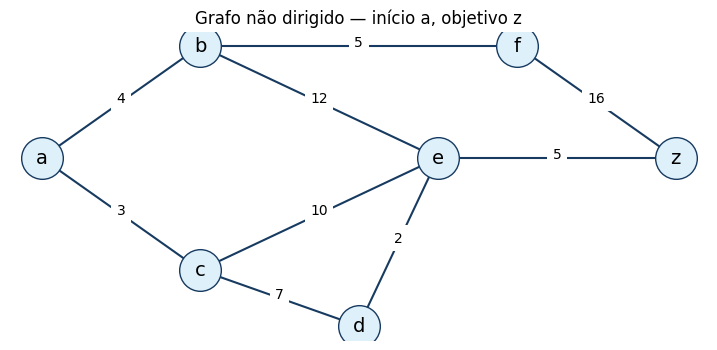


 UCS — ordem de retirada: ['a', 'c', 'b', 'f', 'd', 'e', 'z']


,Operação,OPEN (estado:prioridade),CLOSED
0,Inicial,"[('a', 0)]",[]
1,Expandir a,"[('c', 3), ('b', 4)]",['a']
2,Expandir c,"[('b', 4), ('d', 10), ('e', 13)]","['a', 'c']"
3,Expandir b,"[('f', 9), ('d', 10), ('e', 13)]","['a', 'c', 'b']"
4,Expandir f,"[('d', 10), ('e', 13), ('z', 25)]","['a', 'c', 'b', 'f']"
5,Expandir d,"[('e', 12), ('z', 25)]","['a', 'c', 'b', 'f', 'd']"
6,Expandir e,"[('z', 17)]","['a', 'c', 'b', 'f', 'd', 'e']"
7,Retirar z: objetivo,[],"['a', 'c', 'b', 'f', 'd', 'e']"


,Ao expandir,Estado,g anterior,g candidato,Decisão
0,a,b,NaN,4,Descobrir
1,a,c,NaN,3,Descobrir
2,c,d,NaN,10,Descobrir
3,c,e,NaN,13,Descobrir
4,b,f,NaN,9,Descobrir
5,f,z,NaN,25,Descobrir
6,d,e,13.0,12,Atualizar OPEN
7,e,z,25.0,17,Atualizar OPEN



 A* — ordem de retirada: ['a', 'c', 'b', 'd', 'e', 'z']


,Operação,OPEN (estado:prioridade),CLOSED
0,Inicial,"[('a', 14)]",[]
1,Expandir a,"[('c', 14), ('b', 16)]",['a']
2,Expandir c,"[('b', 16), ('d', 16), ('e', 17)]","['a', 'c']"
3,Expandir b,"[('d', 16), ('e', 17), ('f', 20)]","['a', 'c', 'b']"
4,Expandir d,"[('e', 16), ('f', 20)]","['a', 'c', 'b', 'd']"
5,Expandir e,"[('z', 17), ('f', 20)]","['a', 'c', 'b', 'd', 'e']"
6,Retirar z: objetivo,"[('f', 20)]","['a', 'c', 'b', 'd', 'e']"


,Ao expandir,Estado,g anterior,g candidato,Decisão
0,a,b,NaN,4,Descobrir
1,a,c,NaN,3,Descobrir
2,c,d,NaN,10,Descobrir
3,c,e,NaN,13,Descobrir
4,b,f,NaN,9,Descobrir
5,d,e,13.0,12,Atualizar OPEN
6,e,z,NaN,17,Descobrir


,Algoritmo,Caminho,Custo,Retiradas,Expansões,Estados distintos expandidos,Máximo OPEN
0,UCS,a → c → d → e → z,17,7,6,6,3
1,A*,a → c → d → e → z,17,6,5,5,3


In [2]:
grafo, h = grafo_slides()
desenhar_grafo(grafo)
r1 = mostrar("1", grafo, "a", "z", h, detalhes=True, parametros="Grafo original")

**Resposta 1:**

| Algoritmo | Caminho | Custo | Expansões |
|---|---|---|---|
| UCS | … | … | … |
| A* | … | … | … |

Atualização observada (estado, custo anterior, custo novo e novo pai): …

Interpretação: …

## Experiência 2 — Alterar o custo de uma ligação
Altere apenas `CUSTO_CE`: execute com **10, depois 2 e depois 20**. A ligação c–e muda nos dois sentidos. A tabela de heurísticas mantém os valores originais.

**Questão 2.** Compare o custo e o caminho de A* e UCS. A heurística continua admissível e consistente em todos os casos? Use uma desigualdade apresentada pelo programa. Se A* devolver o ótimo num caso com heurística inadmissível, isso prova que o devolverá sempre?

In [3]:
CUSTO_CE = 10  # ALTERAR: 10, 2, 20
grafo, h = grafo_slides(CUSTO_CE)
verificar(grafo, "z", h)
r2 = mostrar("2", grafo, "a", "z", h, parametros=f"c-e={CUSTO_CE}")

Admissível: True | Consistente: True


,Estado,h,h*,Admissível neste estado
0,a,14,17,True
1,b,12,17,True
2,c,11,14,True
3,d,6,7,True
4,e,4,5,True
5,f,11,16,True
6,z,0,0,True


,Algoritmo,Caminho,Custo,Retiradas,Expansões,Estados distintos expandidos,Máximo OPEN
0,UCS,a → c → d → e → z,17,7,6,6,3
1,A*,a → c → d → e → z,17,6,5,5,3


**Resposta 2:**

| Custo c–e | Custo UCS | Custo A* | h admissível? | h consistente? |
|---|---|---|---|---|
| 10 | … | … | … | … |
| 2 | … | … | … | … |
| 20 | … | … | … | … |

Caminhos que mudaram: …

Desigualdade e interpretação das garantias: …

## Experiência 3 — Dar mais peso à estimativa
O grafo volta aos custos originais. Altere apenas `PESO`: **0, 1, 2 e 5**. A prioridade passa a ser `g + PESO × h`.

Com peso 0 obtém-se UCS; com peso 1, o A* dos slides. Com peso maior que 1, esta experiência é uma variante ponderada, que pode perder a garantia de custo ótimo. A referência UCS é calculada separadamente.

**Questão 3.** Compare custo, expansões e admissibilidade da estimativa ponderada. Identifique um caso em que se reduz o trabalho de procura à custa da qualidade da solução. Um peso maior elimina completamente a influência de `g`?

In [4]:
PESO = 1  # ALTERAR: 0, 1, 2, 5
assert PESO in (0, 1, 2, 5)
grafo, h_original = grafo_slides()
h_ponderada = {v: PESO * valor for v, valor in h_original.items()}
verificar(grafo, "z", h_ponderada)
print(f"A linha A* usa a prioridade g + {PESO} × h original.")
r3 = mostrar("3", grafo, "a", "z", h_ponderada, algoritmos=("UCS", "A*"),
             parametros=f"peso={PESO}")

Admissível: True | Consistente: True


,Estado,h,h*,Admissível neste estado
0,a,14,17,True
1,b,12,17,True
2,c,11,14,True
3,d,6,7,True
4,e,4,5,True
5,f,11,16,True
6,z,0,0,True


A linha A* usa a prioridade g + 1 × h original.


,Algoritmo,Caminho,Custo,Retiradas,Expansões,Estados distintos expandidos,Máximo OPEN
0,UCS,a → c → d → e → z,17,7,6,6,3
1,A*,a → c → d → e → z,17,6,5,5,3


**Resposta 3:**

| Peso | Custo da variante | Expansões | Estimativa admissível? |
|---|---|---|---|
| 0 | … | … | … |
| 1 | … | … | … |
| 2 | … | … | … |
| 5 | … | … | … |

Compromisso observado e papel de g: …

## Experiência 4 — Permitir ou impedir reaberturas
Usamos agora um **grafo dirigido**, com os arcos:

`S → A (3)`, `S → B (1)`, `B → A (1)`, `A → G (3)`.

As estimativas são `h(S)=5`, `h(A)=0`, `h(B)=4`, `h(G)=0`. Altere apenas `REABRIR`: **False e depois True**. A versão False ignora melhorias de estados que já estão em CLOSED; é usada para mostrar a consequência dessa escolha.

**Questão 4.** Registe os dois caminhos e custos. Identifique a melhoria que foi ignorada ou aceite. Com reabertura, quantas expansões existem e quantos estados distintos são expandidos? Explique por que admissibilidade e consistência são propriedades diferentes.

In [5]:
REABRIR = False  # ALTERAR: False e depois True
grafo4 = {"S": {"A": 3, "B": 1}, "A": {"G": 3}, "B": {"A": 1}, "G": {}}
h4 = {"S": 5, "A": 0, "B": 4, "G": 0}
verificar(grafo4, "G", h4)
r4 = mostrar("4", grafo4, "S", "G", h4, algoritmos=("A*",),
             reabrir=REABRIR, detalhes=True, parametros=f"reabrir={REABRIR}")

Admissível: True | Consistente: False


,Estado,h,h*,Admissível neste estado
0,S,5,5,True
1,A,0,3,True
2,B,4,4,True
3,G,0,0,True


,Arco,h(u),c+h(v)
0,S → A,5,3
1,B → A,4,1



 A* — ordem de retirada: ['S', 'A', 'B', 'G']


,Operação,OPEN (estado:prioridade),CLOSED
0,Inicial,"[('S', 5)]",[]
1,Expandir S,"[('A', 3), ('B', 5)]",['S']
2,Expandir A,"[('B', 5), ('G', 6)]","['S', 'A']"
3,Expandir B,"[('G', 6)]","['S', 'A', 'B']"
4,Retirar G: objetivo,[],"['S', 'A', 'B']"


,Ao expandir,Estado,g anterior,g candidato,Decisão
0,S,A,NaN,3,Descobrir
1,S,B,NaN,1,Descobrir
2,A,G,NaN,6,Descobrir
3,B,A,3.0,2,Melhoria ignorada: está em CLOSED


,Algoritmo,Caminho,Custo,Retiradas,Expansões,Estados distintos expandidos,Máximo OPEN
0,A*,S → A → G,6,4,3,3,2


**Resposta 4:**

| Reabrir | Caminho | Custo | Expansões | Estados distintos expandidos |
|---|---|---|---|---|
| False | … | … | … | … |
| True | … | … | … | … |

Estado e melhoria de custo: …

Admissibilidade, consistência e interpretação: …

## Experiência 5 — Escolher uma heurística numa grelha
O agente começa em **S=(0,0)** e termina em **G=(9,3)**. Pode mover-se para cima, baixo, esquerda ou direita. Cada movimento custa 1; não há diagonais. Uma parede obriga a procurar uma passagem.

Altere apenas `HEURISTICA`: **"zero", "euclidiana", "manhattan" e "maximo"**, mantendo `COM_PAREDE=True`. Finalmente, repita **"manhattan" com `COM_PAREDE=False`**.

- `zero`: não fornece informação sobre a distância restante.
- `euclidiana`: distância em linha reta.
- `manhattan`: soma das diferenças absolutas das coordenadas.
- `maximo`: máximo entre Euclidiana e Manhattan em cada estado.

Nos gráficos, azul indica estados expandidos, laranja o caminho e azul-escuro a parede. Um estado expandido não é necessariamente percorrido pelo agente. As barras comparam apenas as configurações já executadas, separando os cenários com e sem parede; repetir uma configuração substitui o seu resultado nas barras.

**Questão 5.** Compare custo, expansões e máximo de OPEN. Qual das duas distâncias domina a outra nesta grelha? O máximo acrescenta informação? Por que motivo ignorar a parede pode fornecer uma estimativa admissível? Sem parede, Manhattan coincide com o custo ótimo restante; isso implica expandir exclusivamente o caminho devolvido? Considere os empates.

,Algoritmo,Caminho,Custo,Retiradas,Expansões,Estados distintos expandidos,Máximo OPEN
0,A*,"(0, 0) → (0, 1) → (0, 2) → (0, 3) → (0, 4) → (...",18,58,57,57,6


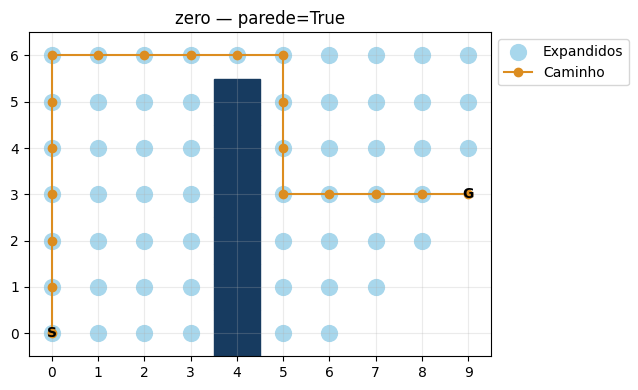

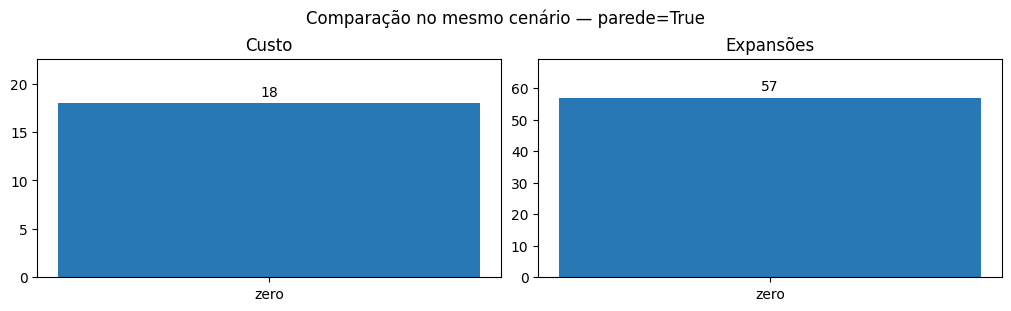

In [6]:
HEURISTICA = "zero"  # ALTERAR: "zero", "euclidiana", "manhattan", "maximo"
COM_PAREDE = True  # manter True nas quatro comparações; depois False com "manhattan"
assert HEURISTICA in ("zero", "euclidiana", "manhattan", "maximo")
grelha, inicio, objetivo, obstaculos = criar_grelha(COM_PAREDE)
def estimativa(pos):
    dx, dy = abs(pos[0]-objetivo[0]), abs(pos[1]-objetivo[1])
    valores = {"zero": 0, "euclidiana": math.hypot(dx,dy), "manhattan": dx+dy,
               "maximo": max(math.hypot(dx,dy),dx+dy)}
    return valores[HEURISTICA]
h5 = {pos: estimativa(pos) for pos in grelha}
r5 = mostrar("5", grelha, inicio, objetivo, h5, algoritmos=("A*",),
             parametros=f"{HEURISTICA}; parede={COM_PAREDE}")
desenhar_grelha(r5["A*"], obstaculos, f"{HEURISTICA} — parede={COM_PAREDE}")
dados = pd.DataFrame([r for r in historico if r["Experiência"] == "5"])
dados = dados.drop_duplicates("Parâmetros", keep="last")
for parede in (True,False):
    grupo=dados[dados["Parâmetros"].str.endswith(f"parede={parede}")]
    if grupo.empty: continue
    fig,eixos=plt.subplots(1,2,figsize=(10,3),constrained_layout=True)
    rotulos=grupo["Parâmetros"].str.split(";").str[0]
    for ax,col in zip(eixos,["Custo","Expansões"]):
        barras=ax.bar(rotulos,grupo[col],color="#2878b5")
        ax.bar_label(barras,padding=3);ax.set_title(col);ax.set_ylim(0,max(grupo[col])*1.2+1)
    fig.suptitle(f"Comparação no mesmo cenário — parede={parede}");plt.show()

**Resposta 5:**

| Heurística | Parede | Custo | Expansões | Máximo OPEN |
|---|---|---|---|---|
| zero | Sim | … | … | … |
| euclidiana | Sim | … | … | … |
| manhattan | Sim | … | … | … |
| maximo | Sim | … | … | … |
| manhattan | Não | … | … | … |

Dominância e combinação: …

Obstáculos, relaxação e admissibilidade: …

Heurística perfeita e empates: …

**Conclusão pessoal:** em que condições escolheria uma heurística mais informativa? Uma redução de expansões garante, por si só, uma redução do tempo total? …

## Histórico e entrega
Execute a célula seguinte para consultar todas as configurações experimentadas. O histórico guarda também repetições; os gráficos da Experiência 5 mostram apenas a execução mais recente de cada configuração.

Antes de entregar, confirme que preencheu as cinco respostas, executou os valores pedidos e guardou os resultados. Os resultados presentes ao abrir o ficheiro correspondem apenas aos valores iniciais; execute as restantes configurações.

In [ ]:
display(pd.DataFrame(historico))

,Experiência,Parâmetros,Algoritmo,Caminho,Custo,Retiradas,Expansões,Estados distintos expandidos,Máximo OPEN
0,1,Grafo original,UCS,a → c → d → e → z,17,7,6,6,3
1,1,Grafo original,A*,a → c → d → e → z,17,6,5,5,3
2,2,c-e=10,UCS,a → c → d → e → z,17,7,6,6,3
3,2,c-e=10,A*,a → c → d → e → z,17,6,5,5,3
4,3,peso=1,UCS,a → c → d → e → z,17,7,6,6,3
5,3,peso=1,A*,a → c → d → e → z,17,6,5,5,3
6,4,reabrir=False,A*,S → A → G,6,4,3,3,2
7,5,zero; parede=True,A*,"(0, 0) → (0, 1) → (0, 2) → (0, 3) → (0, 4) → (...",18,58,57,57,6
